In [1]:
import numpy as np
import pandas as pd
from scipy import optimize
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import SpectralEmbedding
from sklearn.metrics.pairwise import euclidean_distances
from tensorflow.keras.datasets import mnist
import os
from PIL import Image


## MNIST data

In [2]:
# Step 2: Load MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Select only the first 20000 images
x_train = x_train[:20000]
y_train = y_train[:20000]

# Flatten images from 28x28 to 784
x_train_flat = x_train.reshape((x_train.shape[0], -1)).astype(np.float32)
x_test_flat = x_test.reshape((x_test.shape[0], -1)).astype(np.float32)

# Normalize the data
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train_flat)
x_test_scaled = scaler.transform(x_test_flat)

# Apply PCA with 40 components
pca = PCA(n_components=40)
x_train_pca = pca.fit_transform(x_train_scaled)
x_test_pca = pca.transform(x_test_scaled)

## Normal UMAP 

c:\Users\wpbro\OneDrive\Documents\Stat 303-1\Workspace\stat303\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


UMAP(min_dist=0.25, verbose=True)
Tue Jul 15 10:04:30 2025 Construct fuzzy simplicial set
Tue Jul 15 10:04:30 2025 Finding Nearest Neighbors
Tue Jul 15 10:04:30 2025 Building RP forest with 12 trees
Tue Jul 15 10:04:36 2025 NN descent for 14 iterations
	 1  /  14
	 2  /  14
	 3  /  14
	 4  /  14
	Stopping threshold met -- exiting after 4 iterations
Tue Jul 15 10:04:48 2025 Finished Nearest Neighbor Search
Tue Jul 15 10:04:51 2025 Construct embedding


Epochs completed:  12%| █▏         23/200 [00:01]

	completed  0  /  200 epochs
	completed  20  /  200 epochs
	completed  40  /  200 epochs


Epochs completed:  40%| ███▉       79/200 [00:02]

...

	completed  100  /  200 epochs
	completed  120  /  200 epochs


Epochs completed:  79%| ███████▉   158/200 [00:02]

	completed  140  /  200 epochs
	completed  160  /  200 epochs


Epochs completed: 100%| ██████████ 200/200 [00:02]


	completed  180  /  200 epochs
Tue Jul 15 10:04:55 2025 Finished embedding


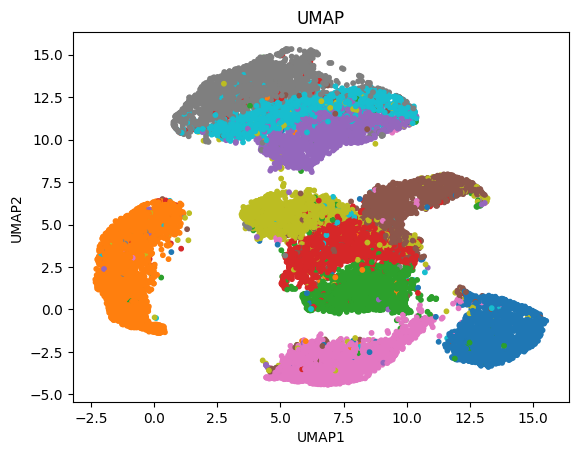

In [4]:
from umap_ import UMAP

model = UMAP(n_neighbors = 15, min_dist = 0.25, n_components = 2, verbose = True)
umap = model.fit_transform(x_train_pca)
plt.scatter(umap[:, 0], umap[:, 1], c = y_train.astype(int), cmap = 'tab10', s = 10)
plt.title('UMAP')
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.show()

## Custom UMAP

Tue Jul 15 09:51:34 2025 Finding nearest neighbors
Tue Jul 15 09:51:34 2025 Finding Nearest Neighbors
Tue Jul 15 09:51:34 2025 Building RP forest with 12 trees
Tue Jul 15 09:51:34 2025 NN descent for 14 iterations
	 1  /  14
	 2  /  14
	 3  /  14
	Stopping threshold met -- exiting after 3 iterations
Tue Jul 15 09:51:35 2025 Finished Nearest Neighbor Search
Tue Jul 15 09:51:35 2025 Computing fuzzy simplicial set
Tue Jul 15 09:51:55 2025 Initializing embedding


  1%|          | 7/1000 [00:00<01:26, 11.54it/s]

	completed  0  /  1000 epochs


 10%|█         | 102/1000 [00:12<01:57,  7.66it/s]

	completed  100  /  1000 epochs


...

 80%|████████  | 802/1000 [01:50<00:24,  7.94it/s]

	completed  800  /  1000 epochs


 90%|█████████ | 902/1000 [02:03<00:12,  7.75it/s]

	completed  900  /  1000 epochs


100%|██████████| 1000/1000 [02:16<00:00,  7.34it/s]


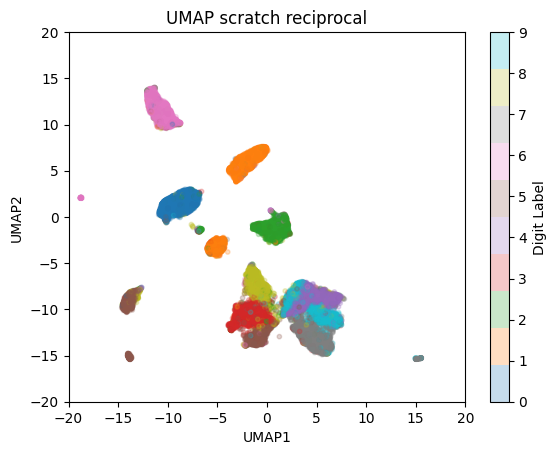

In [5]:
from UMAP.umap_scratch import UMAP_scratch

model = UMAP_scratch(
    n_neighbors=30,
    n_components=2,
    metric="euclidean",
    n_epochs=1000,
    learning_rate=1.0,
    init="spectral",
    min_dist=0.1,
    spread=1.0,
    random_state=42,
    verbose=True,
    similarity='reciprocal'
)
umap = model.fit_transform(x_train_pca)
scatter = plt.scatter(umap[:, 0], umap[:, 1], c=y_train.astype(int), cmap='tab10', s=10, alpha = .25)
plt.title('UMAP scratch reciprocal')
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.colorbar(scatter, label='Digit Label')
plt.xlim(-20, 20)
plt.ylim(-20, 20)
plt.show()

## y = x Line

In [6]:
# Step 1: Generate a line y = x
n_points = 100
x = np.linspace(-10, 10, n_points)
y = x.copy()
data_line = np.vstack([x, y]).T

# Step 2: Standardize
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_line)

# Step 3: PCA to 40 dimensions (even if original is 2D)
# (This just satisfies your model input expectations, you can skip if unnecessary)
pca = PCA(n_components=2)  # use 2 to preserve structure
data_pca = pca.fit_transform(data_scaled)

Tue Jul 15 09:54:17 2025 Finding nearest neighbors
Tue Jul 15 09:54:17 2025 Finding Nearest Neighbors
Tue Jul 15 09:54:17 2025 Building RP forest with 5 trees
Tue Jul 15 09:54:17 2025 NN descent for 7 iterations
	 1  /  7
	 2  /  7
	Stopping threshold met -- exiting after 2 iterations
Tue Jul 15 09:54:17 2025 Finished Nearest Neighbor Search
Tue Jul 15 09:54:17 2025 Computing fuzzy simplicial set
Tue Jul 15 09:54:17 2025 Initializing embedding


  0%|          | 0/500 [00:00<?, ?it/s]

	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs


100%|██████████| 500/500 [00:00<00:00, 4021.89it/s]


	completed  250  /  500 epochs
	completed  300  /  500 epochs
	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs


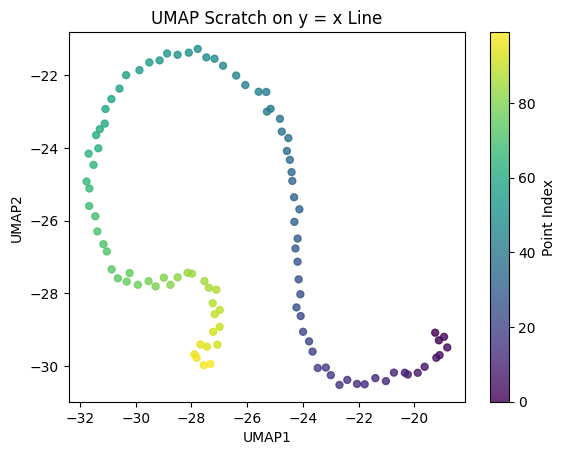

In [7]:
model = UMAP_scratch(
    n_neighbors=15,
    n_components=2,
    metric="euclidean",
    n_epochs=500,
    learning_rate=1.0,
    init="spectral",
    min_dist=0.1,
    spread=1.0,
    random_state=42,
    verbose=True,
    similarity='exp'
)

umap_embedding = model.fit_transform(data_pca)

# Step 5: Plot the embedding
scatter = plt.scatter(umap_embedding[:, 0], umap_embedding[:, 1],
                      c=np.arange(n_points), cmap='viridis', s=25, alpha=0.8)
plt.title('UMAP Scratch on y = x Line')
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.colorbar(scatter, label='Point Index')
plt.show()